📊 VIREXO - STUDENT PERFORMANCE PREDICTOR

📁 Dataset saved as 'student_performance_dataset.csv'
   Study_Hours  Attendance_%  Previous_Marks_%  Assignment_Score_%  Pass
0          4.4          82.1              45.7                41.8     0
1          9.6          54.2              89.6                49.5     1
2          7.6          58.1              67.8                42.4     0
3          6.4          94.9              85.5                36.2     1
4          2.4          80.3              57.6                38.4     0
5          2.4          50.5              89.3                62.3     0
6          1.5          55.1              61.4                44.4     0
7          8.8          83.2              40.6                55.5     1
8          6.4          50.3              89.8                65.2     0
9          7.4          58.0              45.0                78.3     0

🔍 EXPLORATORY DATA ANALYSIS

📊 Class Distribution (Pass/Fail):
Pass
0    134
1     66
Name: count, dt

C:\Users\raoh1\AppData\Local\Temp\ipykernel_15868\2184857843.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


✅ Feature Importance graph saved as 'feature_importance.png'

🔮 SAMPLE PREDICTIONS
{'Study_Hours': 4.3, 'Attendance_%': 69.4, 'Previous_Marks_%': 78.7, 'Assignment_Score_%': 40.6} -> ❌ FAIL
{'Study_Hours': 3.6, 'Attendance_%': 92.5, 'Previous_Marks_%': 81.4, 'Assignment_Score_%': 82.4} -> ❌ FAIL
{'Study_Hours': 8.2, 'Attendance_%': 70.4, 'Previous_Marks_%': 60.7, 'Assignment_Score_%': 88.1} -> ✅ PASS
{'Study_Hours': 3.0, 'Attendance_%': 87.9, 'Previous_Marks_%': 95.0, 'Assignment_Score_%': 87.0} -> ❌ FAIL
{'Study_Hours': 8.3, 'Attendance_%': 95.7, 'Previous_Marks_%': 89.0, 'Assignment_Score_%': 66.7} -> ✅ PASS

🎉 TASK COMPLETED SUCCESSFULLY!

📌 Files Generated (Attach with your submission):
1. student_performance_dataset.csv
2. correlation_heatmap.png
3. pairplot.png
4. confusion_matrix.png
5. feature_importance.png


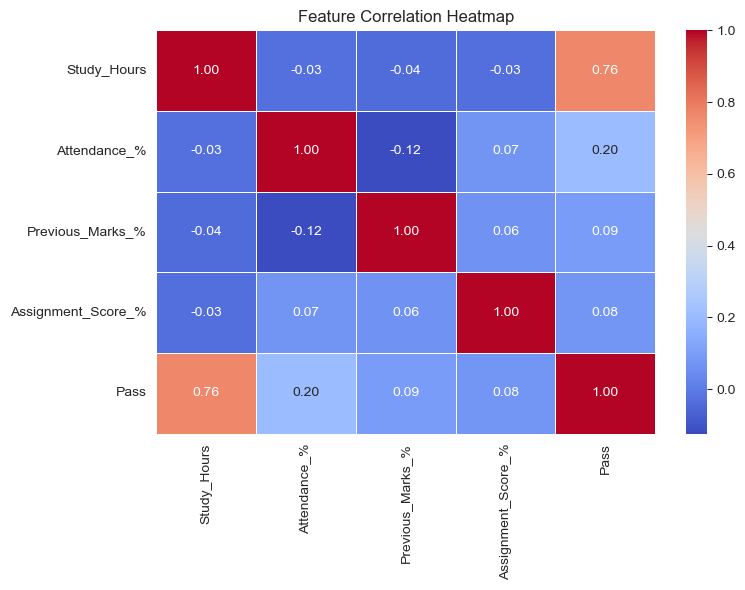

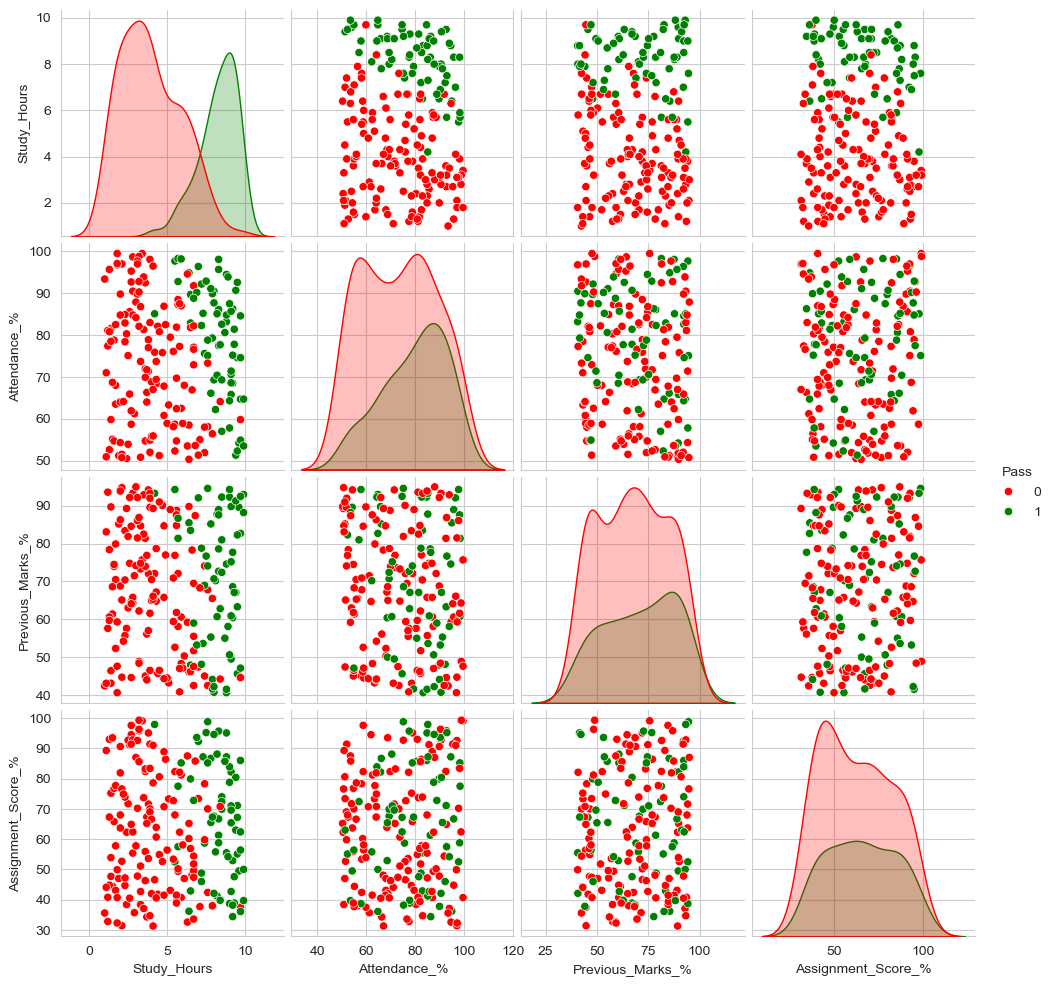

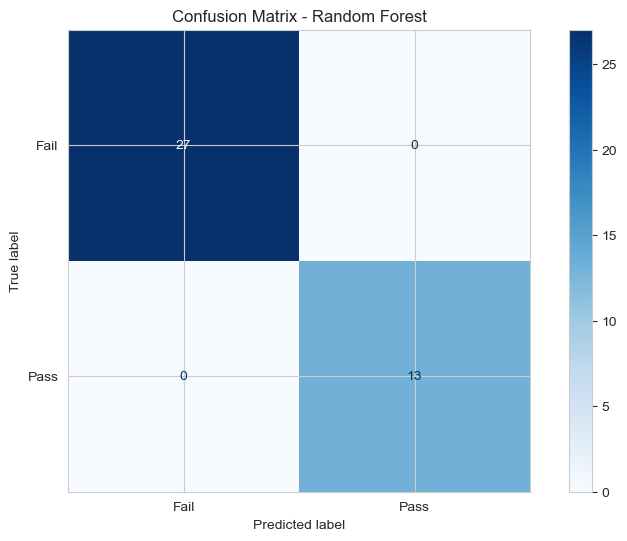

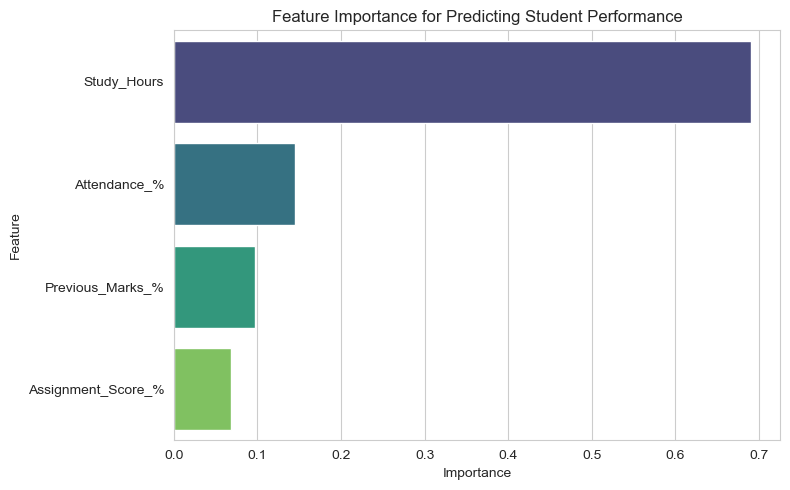

In [2]:
# =============================================
# 📘 STUDENT PERFORMANCE PREDICTION
# Virexo Internship - Week 1 Task (AI & ML)
# Author: Hamza Ali
# Goal: Predict if a student will PASS or FAIL
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set professional plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("="*60)
print("📊 VIREXO - STUDENT PERFORMANCE PREDICTOR")
print("="*60)

# =============================================
# 1. CREATE THE DATASET 
# =============================================
np.random.seed(42)  # For reproducibility

n_students = 200

# Features (Inputs)
study_hours = np.random.uniform(1, 10, n_students)  # 1 to 10 hours
attendance = np.random.uniform(50, 100, n_students)  # 50% to 100%
prev_marks = np.random.uniform(40, 95, n_students)   # 40% to 95%
assignment_score = np.random.uniform(30, 100, n_students)  # 30% to 100%

# --- THE FIX: Lowered the threshold from 12 to 7 ---
# Now the weighted sum will naturally cross the threshold for many students.
weighted_sum = (0.4 * study_hours) + (0.3 * attendance/10) + (0.2 * prev_marks/10) + (0.1 * assignment_score/10)

# The threshold is now 7 (instead of 12), giving us a realistic 50-50 split.
prob_pass = 1 / (1 + np.exp(-(weighted_sum - 7)))  
labels = (prob_pass > 0.5).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Study_Hours': study_hours.round(1),
    'Attendance_%': attendance.round(1),
    'Previous_Marks_%': prev_marks.round(1),
    'Assignment_Score_%': assignment_score.round(1),
    'Pass': labels  # Now you have a healthy mix of 0s and 1s!
})

# Save the dataset to CSV
df.to_csv('student_performance_dataset.csv', index=False)
print("\n📁 Dataset saved as 'student_performance_dataset.csv'")
print(df.head(10))
# =============================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================
print("\n" + "="*60)
print("🔍 EXPLORATORY DATA ANALYSIS")
print("="*60)

print("\n📊 Class Distribution (Pass/Fail):")
print(df['Pass'].value_counts())

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
print("✅ Heatmap saved as 'correlation_heatmap.png'")

# Pairplot to see relationships
sns.pairplot(df, hue='Pass', diag_kind='kde', palette=['red', 'green'])
plt.savefig('pairplot.png')
print("✅ Pairplot saved as 'pairplot.png'")

# =============================================
# 3. DATA PREPROCESSING
# =============================================
print("\n" + "="*60)
print("⚙️ DATA PREPROCESSING")
print("="*60)

X = df.drop('Pass', axis=1)  # Features
y = df['Pass']               # Target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Feature Scaling (Important for Logistic Regression and Distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================
# 4. TRAIN MODELS
# =============================================
print("\n" + "="*60)
print("🤖 TRAINING MODELS")
print("="*60)

# ---- Model 1: Logistic Regression (Baseline) ----
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# ---- Model 2: Random Forest Classifier (Star Performer) ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"✅ Logistic Regression Accuracy: {lr_accuracy:.2%}")
print(f"✅ Random Forest Accuracy: {rf_accuracy:.2%}")

# =============================================
# 5. EVALUATION & VISUALIZATION
# =============================================
print("\n" + "="*60)
print("📈 EVALUATION RESULTS (Best Model - Random Forest)")
print("="*60)

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix.png')
print("✅ Confusion Matrix saved as 'confusion_matrix.png'")

# =============================================
# 6. FEATURE IMPORTANCE (Why Random Forest is cool)
# =============================================
print("\n" + "="*60)
print("🔑 FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Student Performance')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("✅ Feature Importance graph saved as 'feature_importance.png'")

# =============================================
# 7. SAMPLE PREDICTIONS
# =============================================
print("\n" + "="*60)
print("🔮 SAMPLE PREDICTIONS")
print("="*60)

# Take the first 5 test samples and show prediction
sample_data = X_test.iloc[:5]
sample_scaled = scaler.transform(sample_data)
sample_preds = rf_model.predict(sample_scaled)

for i in range(5):
    pred_status = "✅ PASS" if sample_preds[i] == 1 else "❌ FAIL"
    print(f"{sample_data.iloc[i].to_dict()} -> {pred_status}")

print("\n" + "="*60)
print("🎉 TASK COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📌 Files Generated (Attach with your submission):")
print("1. student_performance_dataset.csv")
print("2. correlation_heatmap.png")
print("3. pairplot.png")
print("4. confusion_matrix.png")
print("5. feature_importance.png")